<a href="https://colab.research.google.com/github/SeratAftab131/Fake-Job-Detection/blob/main/Fake_Job_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("fake_job_postings.csv")
df.head()

Saving fake_job_postings.csv to fake_job_postings.csv


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [8]:
df.shape

(17880, 18)

In [9]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [11]:
text_cols = ["description", "requirements", "company_profile", "benefits"]

for col in text_cols:
    df[col] = df[col].fillna("")

In [12]:
df[text_cols].isnull().sum()

,0
description,0
requirements,0
company_profile,0
benefits,0


In [13]:
df["text"] = df["description"] + " " + df["requirements"] + " " + df["company_profile"] + " " + df["benefits"]

In [14]:
df["text"].head()

,text
0,"Food52, a fast-growing, James Beard Award-winn..."
1,Organised - Focused - Vibrant - Awesome!Do you...
2,"Our client, located in Houston, is actively se..."
3,THE COMPANY: ESRI – Environmental Systems Rese...
4,JOB TITLE: Itemization Review ManagerLOCATION:...


In [15]:
df["missing_salary"] = df["salary_range"].isnull().astype(int)
df["no_profile"] = (df["company_profile"] == "").astype(int)
df["no_benefits"] = (df["benefits"] == "").astype(int)
df["no_logo"] = (df["has_company_logo"] == 0).astype(int)
df["no_questions"] = (df["has_questions"] == 0).astype(int)

In [16]:
keywords = ["urgent", "immediately", "quick", "earn money", "work from home"]

for word in keywords:
    df[word] = df["text"].str.lower().str.contains(word).astype(int)

In [17]:
df["fraudulent"].value_counts()

,count
fraudulent,
0,17014
1,866


In [18]:
df["fraudulent"].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["fraudulent"],
    random_state=42
)

In [20]:
train_df["fraudulent"].value_counts()

,count
fraudulent,
0,13611
1,693


In [21]:
test_df["fraudulent"].value_counts()

,count
fraudulent,
0,3403
1,173


In [22]:
len(train_df)

14304

In [23]:
len(test_df)

3576

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_text = tfidf.fit_transform(train_df["text"])

In [26]:
feature_cols = [
    "missing_salary",
    "no_profile",
    "no_benefits",
    "no_logo",
    "no_questions"
] + [col for col in train_df.columns if col not in df.columns]

In [27]:
X_struct = train_df[feature_cols].values

In [28]:
from scipy.sparse import hstack

X_train = hstack([X_text, X_struct])
y_train = train_df["fraudulent"]

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
X_test_text = tfidf.transform(test_df["text"])

In [35]:
X_test_struct = test_df[feature_cols].values

In [36]:
from scipy.sparse import hstack

X_test = hstack([X_test_text, X_test_struct])

In [37]:
y_test = test_df["fraudulent"]

In [38]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [39]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("KNN")
print(classification_report(y_test, y_pred_knn))

Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.71      0.79      3576
weighted avg       0.97      0.97      0.97      3576

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.97      0.58      0.73       173

    accuracy                           0.98      3576
   macro avg       0.98      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576

SVM
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.94      0.72      0.82       173

    accuracy                           0.98      3576
   macro avg       0.96      0.86      0.90      3576
weighted avg       0.98      0.98   

In [40]:
from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, y_pred_lr))
print("RF:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("KNN:", accuracy_score(y_test, y_pred_knn))

LR: 0.9723154362416108
RF: 0.9790268456375839
SVM: 0.9843400447427293
KNN: 0.9756711409395973


In [41]:
!pip install shap

In [42]:
import shap

In [43]:
model = rf

In [44]:
explainer = shap.TreeExplainer(model)

In [45]:
X_test = X_test.tocsr()

In [46]:
# To correctly explain test_df samples, X_sample should be from X_test
X_sample = X_test[:100].toarray()

In [47]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

In [48]:
print(X_sample.shape)
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)
(5005, 2)


In [49]:
print(X_train.shape)

(14304, 5005)


In [50]:
X_train = X_train.tocsr()

In [51]:
X_sample = X_train[:100].toarray()

In [52]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

In [53]:
print(X_sample.shape)
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)
(5005, 2)


In [54]:
print(X_sample.shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)


In [55]:
print(X_sample.shape)
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
(5005, 2)
(5005, 2)


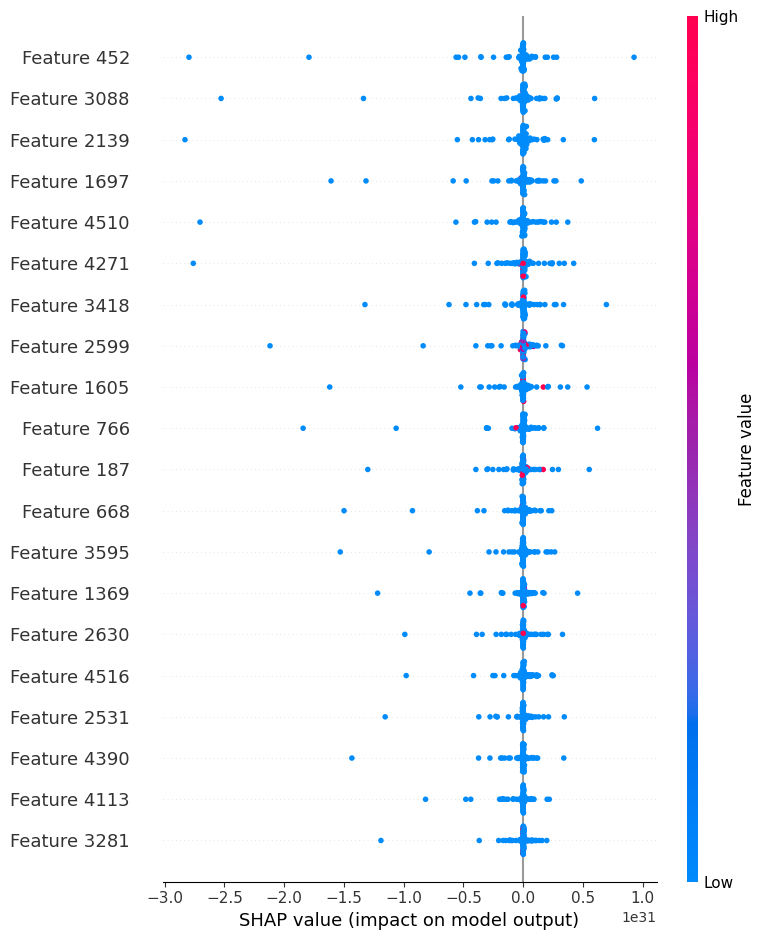

In [56]:
shap.summary_plot(shap_values[:,:,1], X_sample)

In [57]:
print(X_sample.shape)
print(len(shap_values))
print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 5005)
100
(5005, 2)
(5005, 2)


In [58]:
import shap

explainer = shap.Explainer(rf, X_sample)
shap_values = explainer(X_sample)

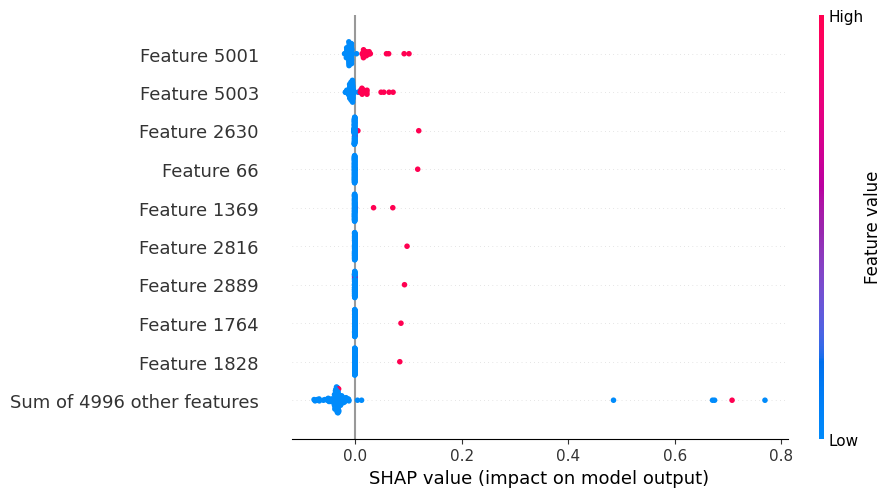

In [59]:
shap.plots.beeswarm(shap_values[:,:, 1])

In [60]:
feature_names = list(tfidf.get_feature_names_out()) + feature_cols
X_sample.shape[1] == len(feature_names)

True

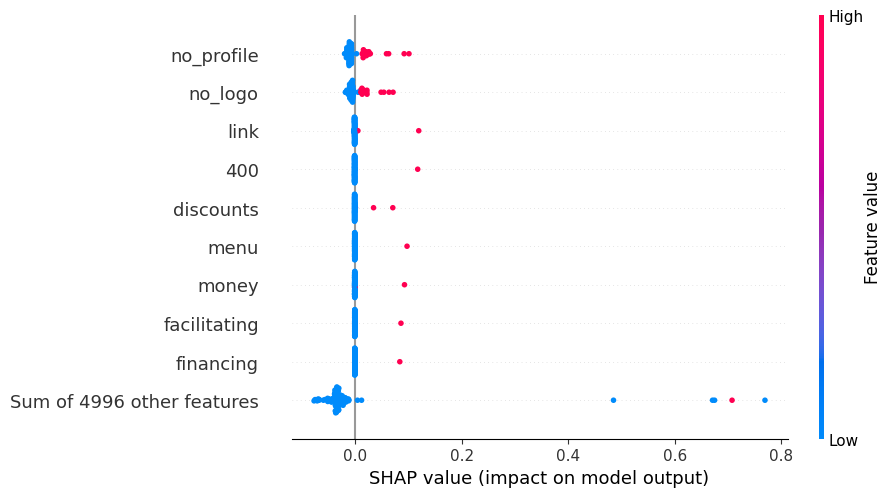

In [61]:
shap_explanation_for_class_1 = shap_values[:, :, 1]
shap_explanation_for_class_1.feature_names = feature_names
shap.plots.beeswarm(shap_explanation_for_class_1)

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [63]:
evaluate_model(lr, X_test, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")
evaluate_model(svm, X_test, y_test, "SVM")
evaluate_model(knn, X_test, y_test, "KNN")


===== Logistic Regression =====
Accuracy: 0.9723154362416108

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.71      0.79      3576
weighted avg       0.97      0.97      0.97      3576

Confusion Matrix:
[[3403    0]
 [  99   74]]

===== Random Forest =====
Accuracy: 0.9790268456375839

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.97      0.58      0.73       173

    accuracy                           0.98      3576
   macro avg       0.98      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576

Confusion Matrix:
[[3400    3]
 [  72  101]]

===== SVM =====
Accuracy: 0.9843400447427293

Classification Report:
               pre

In [64]:
import numpy as np
import pandas as pd

mean_shap = np.abs(shap_explanation_for_class_1.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_shap
})

shap_importance = shap_importance.sort_values(by="importance", ascending=False)

print(shap_importance.head(10))

           feature  importance
5001    no_profile    0.015366
5003       no_logo    0.011559
2630          link    0.002484
66             400    0.002346
1369     discounts    0.002103
2816          menu    0.001945
2889         money    0.001850
1764  facilitating    0.001717
1828     financing    0.001673
4374      suitable    0.001621


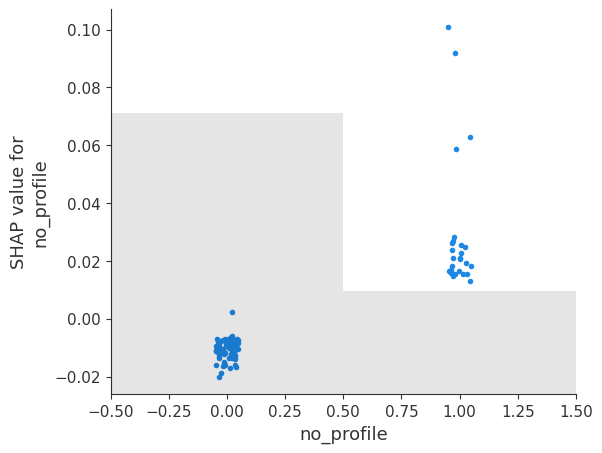

In [65]:
shap.plots.scatter(shap_explanation_for_class_1[:, "no_profile"])

In [66]:
from sklearn.utils import resample

In [67]:
class_weight="balanced"

In [68]:
probs = rf.predict_proba(X_test)[:, 1]

In [72]:
def assign_risk(prob):
    if prob < 0.2:
        return "Low Risk"
    elif prob < 0.5:
        return "Medium Risk"
    else:
        return "High Risk"

In [73]:
risk_levels = [assign_risk(p) for p in probs]

test_df["fraud_probability"] = probs
test_df["risk_level"] = risk_levels

test_df[["fraud_probability", "risk_level"]].head()

,fraud_probability,risk_level
16995,0.03,Low Risk
9357,0.00,Low Risk
11561,0.00,Low Risk
1105,0.00,Low Risk
1980,0.02,Low Risk


In [71]:
print(test_df["risk_level"].value_counts())

risk_level
Low Risk       3431
High Risk        89
Medium Risk      56
Name: count, dtype: int64


In [75]:
test_df[["fraud_probability", "risk_level"]]

,fraud_probability,risk_level
16995,0.03,Low Risk
9357,0.00,Low Risk
11561,0.00,Low Risk
1105,0.00,Low Risk
1980,0.02,Low Risk
...,...,...
7039,0.03,Low Risk
14472,0.00,Low Risk
14453,0.08,Low Risk
6296,0.08,Low Risk


In [77]:
shap_explanation_for_class_1
def get_top_features(shap_values, feature_names, top_n=3):
    top_features_list = []

    for i in range(len(shap_values)):
        values = shap_values[i]

        df_temp = pd.DataFrame({
            "feature": feature_names,
            "impact": values
        })

        df_temp = df_temp[df_temp["impact"] > 0]

        df_temp = df_temp.sort_values(by="impact", ascending=False)

        top_features = df_temp["feature"].head(top_n).tolist()

        top_features_list.append(top_features)

    return top_features_list

In [79]:
top_features_per_row = get_top_features(
    shap_explanation_for_class_1.values,
    feature_names
)

In [83]:
X_sample = X_test[:100].toarray()

explainer = shap.Explainer(rf, X_sample)
shap_values = explainer(X_sample)

shap_explanation_for_class_1 = shap_values[:, :, 1]

In [85]:
top_features_per_row = get_top_features(
    shap_explanation_for_class_1.values,
    feature_names
)

test_df["top_risk_features"] = None

# Get the number of samples for which top features were generated
num_samples_to_explain = len(top_features_per_row)

# Create a pandas Series from the list of top features, ensuring object dtype
# and aligning the index with the corresponding test_df rows.
features_series = pd.Series(
    top_features_per_row,
    index=test_df.index[:num_samples_to_explain],
    dtype=object
)

# Assign this Series to the 'top_risk_features' column for the selected rows
test_df.loc[test_df.index[:num_samples_to_explain], "top_risk_features"] = features_series

In [88]:
test_df[["fraud_probability", "risk_level", "top_risk_features"]]

,fraud_probability,risk_level,top_risk_features
16995,0.03,Low Risk,"[no_profile, rn, bed]"
9357,0.00,Low Risk,"[retirement, scrum, word]"
11561,0.00,Low Risk,"[employ, level, admin]"
1105,0.00,Low Risk,"[maximizing, vp, resistance]"
1980,0.02,Low Risk,"[exploration, log, oil]"
...,...,...,...
7039,0.03,Low Risk,None
14472,0.00,Low Risk,None
14453,0.08,Low Risk,None
6296,0.08,Low Risk,None


In [89]:
def generate_clean_rule(features):
    if not isinstance(features, list) or len(features) == 0:
        return "No strong fraud indicators"

    rules = []

    for f in features:
        if f == "no_profile":
            rules.append("company profile is missing")
        elif f == "no_logo":
            rules.append("company logo is missing")
        elif f == "missing_salary":
            rules.append("salary is not provided")
        elif f == "no_benefits":
            rules.append("benefits are not mentioned")
        elif f == "no_questions":
            rules.append("no screening questions")
        elif f in ["urgent", "immediately", "quick", "earn money", "work from home"]:
            rules.append(f"uses suspicious keyword '{f}'")
        else:
            rules.append(f"contains term '{f}'")

    return "High Risk because " + ", ".join(rules)

In [90]:
test_df["rule"] = test_df["top_risk_features"].apply(generate_clean_rule)

In [91]:
top_global = shap_importance.head(10)["feature"].tolist()

global_rules = []

for f in top_global:
    if f.startswith("no_"):
        global_rules.append(f"If {f.replace('_', ' ')} → High Risk")
    elif f in ["urgent", "immediately", "quick", "earn", "work", "home"]:
        global_rules.append(f"If text contains '{f}' → Fraud likely")
    else:
        global_rules.append(f"'{f}' is a strong fraud indicator")

for r in global_rules:
    print("-", r)

- If no profile → High Risk
- If no logo → High Risk
- 'link' is a strong fraud indicator
- '400' is a strong fraud indicator
- 'discounts' is a strong fraud indicator
- 'menu' is a strong fraud indicator
- 'money' is a strong fraud indicator
- 'facilitating' is a strong fraud indicator
- 'financing' is a strong fraud indicator
- 'suitable' is a strong fraud indicator


In [93]:
test_df[["fraud_probability", "risk_level", "top_risk_features", "rule"]]

,fraud_probability,risk_level,top_risk_features,rule
16995,0.03,Low Risk,"[no_profile, rn, bed]","High Risk because company profile is missing, ..."
9357,0.00,Low Risk,"[retirement, scrum, word]","High Risk because contains term 'retirement', ..."
11561,0.00,Low Risk,"[employ, level, admin]","High Risk because contains term 'employ', cont..."
1105,0.00,Low Risk,"[maximizing, vp, resistance]","High Risk because contains term 'maximizing', ..."
1980,0.02,Low Risk,"[exploration, log, oil]","High Risk because contains term 'exploration',..."
...,...,...,...,...
7039,0.03,Low Risk,None,No strong fraud indicators
14472,0.00,Low Risk,None,No strong fraud indicators
14453,0.08,Low Risk,None,No strong fraud indicators
6296,0.08,Low Risk,None,No strong fraud indicators


In [97]:
def generate_clean_rule(features, risk_level):
    if not isinstance(features, list):
        return "No explanation available"

    if risk_level == "Low Risk":
        return "Low risk job — no strong fraud indicators"

    elif risk_level == "Medium Risk":
        return "Medium risk job — some suspicious indicators: " + ", ".join(features)

    else:  # High Risk
        return "High risk job — strong fraud indicators: " + ", ".join(features)

In [98]:
test_df["rule"] = test_df.apply(
    lambda row: generate_clean_rule(row["top_risk_features"], row["risk_level"]),
    axis=1
)

In [99]:
test_df[["fraud_probability", "risk_level", "top_risk_features", "rule"]]

,fraud_probability,risk_level,top_risk_features,rule
16995,0.03,Low Risk,"[no_profile, rn, bed]",Low risk job — no strong fraud indicators
9357,0.00,Low Risk,"[retirement, scrum, word]",Low risk job — no strong fraud indicators
11561,0.00,Low Risk,"[employ, level, admin]",Low risk job — no strong fraud indicators
1105,0.00,Low Risk,"[maximizing, vp, resistance]",Low risk job — no strong fraud indicators
1980,0.02,Low Risk,"[exploration, log, oil]",Low risk job — no strong fraud indicators
...,...,...,...,...
7039,0.03,Low Risk,None,No explanation available
14472,0.00,Low Risk,None,No explanation available
14453,0.08,Low Risk,None,No explanation available
6296,0.08,Low Risk,None,No explanation available


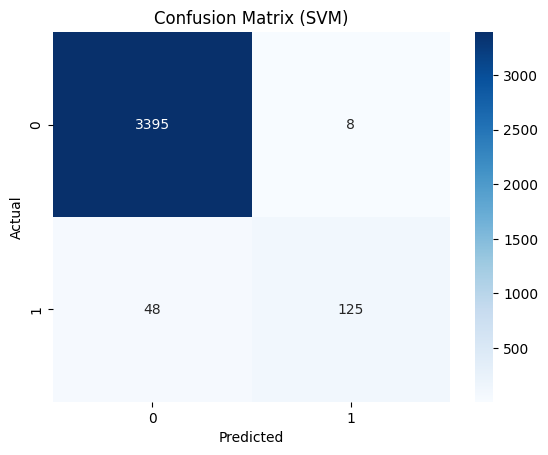

In [102]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()

In [105]:
test_df["predicted"] = y_pred_svm
good = test_df[
    (test_df["fraudulent"] == test_df["predicted"]) &
    (test_df["rule"].notnull())
].iloc[0]

In [106]:
bad = test_df[
    (test_df["fraudulent"] != test_df["predicted"]) &
    (test_df["rule"].notnull())
].iloc[0]

In [112]:
good["text"][:100]

'Our client, located in Urban, IL, is looking for an ER RN to become a member of their team ASAP!Our '

In [113]:
bad["text"][:100]

'Looking for motivated and hard working individuals!*Must be at least 18*Learn entrepreneurial and re'